In [2]:
%xmode minimal

import os
import json

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disable GPU devices
os.environ["TFDS_DATA_DIR"] = os.path.expanduser("~/tensorflow_datasets")  # default location of tfds database

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers, models

import tensorflow as tf
import tensorflow_datasets as tfds

import librosa
import librosa.display

import numpy as np
from matplotlib import pyplot as plt

from pathlib import Path

from IPython.display import Audio

# Turn off logging for TF
import logging
tf.get_logger().setLevel(logging.ERROR)

# from tensorflow.python.client import device_lib
# print(device_lib.list_local_devices())

Exception reporting mode: Minimal


2024-05-24 13:53:36.853338: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-24 13:53:36.857551: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-24 13:53:36.914888: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-24 13:53:37.819124: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/volatile/home/bm279471/Documents/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import dpmhm
# dpmhm.datasets.get_dataset_list()

from dpmhm.datasets import preprocessing, feature, utils

outdir = Path('/volatile/home/bm279471/tmp/AE')
os.makedirs(outdir, exist_ok=True)

takesamples = lambda ds,n=1: list(ds.take(n).as_numpy_iterator())

In [4]:
dataset_name = 'CWRU'

ds_all, ds_info = tfds.load(
    dataset_name,
    with_info=True,
)

ds0 = ds_all['train']

2024-05-24 13:53:39.825504: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2024-05-24 13:53:39.825539: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:134] retrieving CUDA diagnostic information for host: is230816
2024-05-24 13:53:39.825567: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:141] hostname: is230816
2024-05-24 13:53:39.825685: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:165] libcuda reported version is: 535.171.4
2024-05-24 13:53:39.825712: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:169] kernel reported version is: 535.171.4
2024-05-24 13:53:39.825719: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:248] kernel version seems to match DSO: 535.171.4


In [5]:
from dpmhm.datasets import transformer, feature

compactor = transformer.DatasetCompactor(ds0,
                                         channels=['DE', 'FE', 'BA'],
                                         keys=['FaultLocation', 'FaultComponent', 'FaultSize'],
                                         resampling_rate=12000)

# Feature extractor
# Spectrogram is computed on a time window of 0.025 second every 0.0125 second, then converted to decibel scale.
_func = lambda x, sr: feature.spectral_features(x, sr, 'spectrogram',
#                                                 n_mfcc=256,
                                                time_window=0.025, hop_step=0.0125, n_fft=512,
                                                normalize=False, to_db=True)[0]

extractor = transformer.FeatureExtractor(compactor.dataset, _func)

# A window of width w correspond to w*0.0125 seconds
window = transformer.WindowSlider(extractor.dataset, window_size=(64,64), hop_size=(32,32))
# window = transformer.WindowSlider(extractor.dataset, window_size=(256, 80), hop_size=40)  # 1s, full bandwidth
# window = transformer.WindowSlider(extractor.dataset, window_size=64, hop_size=32)

compactor.dataset.element_spec

{'label': TensorSpec(shape=(), dtype=tf.string, name=None),
 'sampling_rate': TensorSpec(shape=(), dtype=tf.int32, name=None),
 'signal': TensorSpec(shape=(3, None), dtype=tf.float32, name=None)}

2024-05-24 13:53:41.993940: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-05-24 13:53:42.393063: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-05-24 13:53:42.805932: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-05-24 13:53:43.409756: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-05-24 13:53:43.926855: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


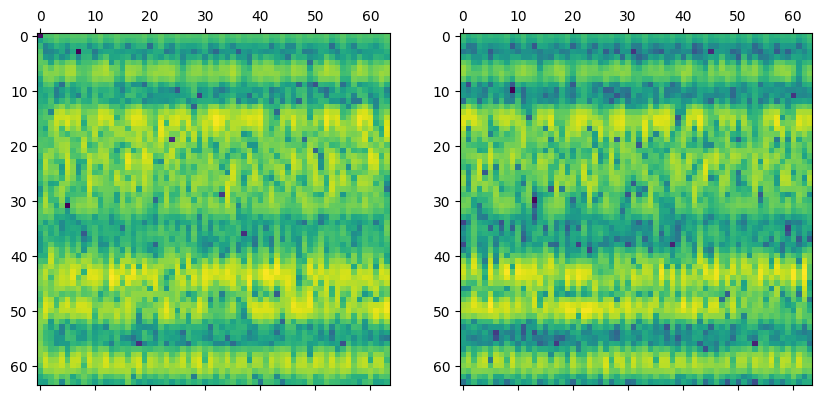

In [6]:
labels = list(compactor.full_label_dict.keys())

eles = list(window.dataset.take(10).as_numpy_iterator())

fig, axes = plt.subplots(1,2,figsize=(10,5))

axes[0].matshow(eles[0]['feature'][0])
axes[1].matshow(eles[9]['feature'][0])

In [7]:
preproc = preprocessing.get_mapping_supervised(labels)

with open(outdir/'labels.json', 'w') as fp:
    json.dump(compactor.full_label_dict,fp)
    
ds_window = window.dataset.map(preproc, num_parallel_calls=tf.data.AUTOTUNE)

eles = list(ds_window.take(10).as_numpy_iterator())
input_shape = eles[0][0].shape

# Ensure the input shape
# An issue in Keras 3:
# https://github.com/tensorflow/tensorflow/issues/64177
ds_window = ds_window.map(lambda x,y: (tf.ensure_shape(x, input_shape), y), num_parallel_calls=tf.data.AUTOTUNE)

ds_window.save(str(outdir/'cwru'))
ds_window.element_spec

2024-05-24 13:53:44.810284: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-05-24 13:53:50.502006: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(TensorSpec(shape=(64, 64, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int32, name=None))

In [8]:
ds_window = tf.data.Dataset.load(str(outdir/'cwru'))

with open(outdir/'labels.json', 'r') as fp:
    labels = list(json.load(fp).keys())

eles = list(ds_window.take(10).as_numpy_iterator())
input_shape = eles[0][0].shape
print(input_shape)

n_classes = len(labels)+1  # must add one for the outlier class, Keras uses zero-based class labels.
print(f"Number of class: {n_classes}")

splits = {'train':0.7, 'val':0.2, 'test':0.1}
ds_split = utils.split_dataset(ds_window, splits, ds_size=int(ds_window.cardinality()))

(64, 64, 3)
Number of class: 30
16296


2024-05-24 13:53:50.595188: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
ele = takesamples(ds_split['train'])[0]

# Create the valing/validation/test set with mini-batches
batch_size = 16

ds_size = 5000  # use a large number

ds_train = ds_split['train'].map(lambda x,l:(x,x))
ds_val = ds_split['val'].map(lambda x,l:(x,x)).batch(batch_size)
ds_test = ds_split['test'].map(lambda x,l:x).batch(1)  # input only, batch size set to 1

ds_train = ds_train.shuffle(ds_size, reshuffle_each_iteration=True).batch(batch_size).prefetch(tf.data.AUTOTUNE)

ds_train.element_spec

2024-05-24 13:53:51.864510: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None))

In [10]:
from dpmhm.models.ul import autoencoder

input_shape = ele[0].shape
print(input_shape)

# n_classes = len(labels)+1  # must add one for the outlier class, Keras uses zero-based class labels.

config = autoencoder.Config(input_shape=input_shape)  # configuration for AE

model = autoencoder.CAES(config)  # build an AE model

#model.summary()
#model.encoder.summary()
#model.decoder.summary()
model.autoencoder.summary()

(64, 64, 3)


Model: "auto-encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_enc (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1_enc (MaxPooling2D)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_enc (BatchNormalization)    │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_enc (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2_enc (MaxPooling2D)        │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_enc (BatchNormalization)    │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_enc (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3_enc (MaxPooling2D)        │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_enc (BatchNormalization)    │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1_enc (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1_dec (Dense)                 │ (None, 8192)           │     1,056,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_dec (BatchNormalization)    │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ups3_dec (UpSampling2D)         │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tconv3_dec (Conv2DTranspose)    │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_dec (BatchNormalization)    │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ups2_dec (UpSampling2D)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tconv2_dec (Conv2DTranspose)    │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_dec (BatchNormalization)    │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ups1_dec (UpSampling2D)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tconv1_dec (Conv2DTranspose)    │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,293,635 (8.75 MB)

 Trainable params: 2,292,739 (8.75 MB)

 Non-trainable params: 896 (3.50 KB)

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.MeanSquaredError(),
    # metrics=['accuracy'],
)

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=10,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=3),
)

Epoch 1/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 72s 94ms/step - loss: 65.2826 - val_loss: 36.1358
Epoch 2/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 67s 92ms/step - loss: 35.6146 - val_loss: 33.6604
Epoch 3/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 68s 93ms/step - loss: 35.1999 - val_loss: 33.0340
Epoch 4/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 68s 93ms/step - loss: 32.8813 - val_loss: 33.3181
Epoch 5/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 72s 99ms/step - loss: 33.0253 - val_loss: 32.0144
Epoch 6/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 72s 99ms/step - loss: 32.5531 - val_loss: 33.0744
Epoch 7/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 67s 93ms/step - loss: 32.5671 - val_loss: 31.9375
Epoch 8/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 72s 99ms/step - loss: 31.8121 - val_loss: 32.0918
Epoch 9/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 69s 95ms/step - loss: 31.6435 - val_loss: 31.5464
Epoch 10/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 69s 95ms/step - loss: 31.7100 - val_loss: 31.3698


In [19]:
model.save('/volatile/home/bm279471/tmp/ae_[64X64].keras')

In [ ]:
# model = tf.keras.models.load_model('/volatile/home/bm279471/tmp/ae')

In [20]:
X0 = list(ds_test.as_numpy_iterator())
X1 = [model(x, training=False) for x in X0]

err = [np.linalg.norm(y-x) for x,y in zip(X0,X1)]

2024-05-24 14:16:04.511908: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


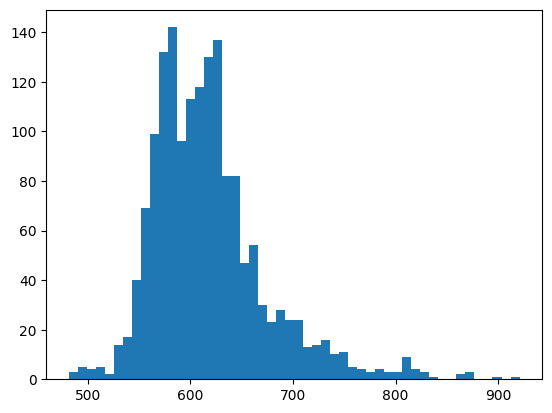

In [22]:
_=plt.hist(err, bins=50)

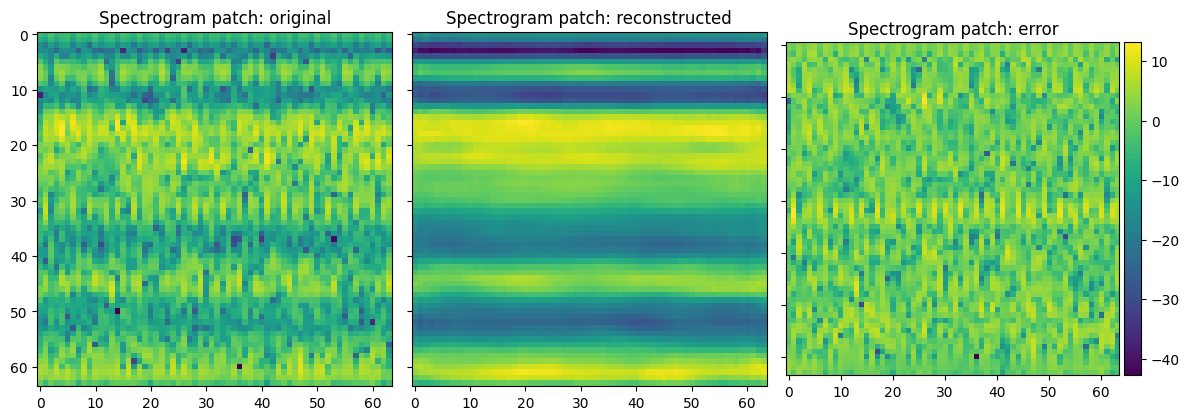

In [25]:
n = 1; ch = 0
a = X0[n][0, :,:,ch]
b = X1[n][0, :,:,ch]

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(1,3, figsize=(12,12), sharey=True)
ax = axes[0]
ax.imshow(a)
ax.set_title('Spectrogram patch: original')

ax = axes[1]
ax.imshow(b)
ax.set_title('Spectrogram patch: reconstructed')

ax = axes[2]
im = ax.imshow(a-b); #plt.colorbar()
ax.set_title('Spectrogram patch: error')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

# im = ax.imshow(data, cmap='bone')

fig.colorbar(im, cax=cax, orientation='vertical')
fig.tight_layout()